# 01 data understanding


In [1]:
from pathlib import Path

# Works whether the notebook is run from the project root or from the notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## load dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(DATA_DIR / "carbon_footprint_dataset.xlsx")  # raw dataset load
df.head()  # preview first 5 rows


,household_size,annual_income_usd,electricity_kwh_per_month,natural_gas_therms_per_month,fuel_liters_per_month,food_spend_usd_per_month,meat_kg_per_month,waste_kg_per_month,public_transport_km_per_month,car_km_per_month,estimated_co2_kg_per_month
0,4,29397,1143.4,35.6,145.2,1147.93,7.06,57.1,42.1,368.9,1368.87
1,5,146800,542.0,145.7,163.6,1047.98,17.88,21.4,237.2,404.6,1996.21
2,3,134180,434.3,27.1,42.7,1299.29,18.93,49.6,109.1,773.4,1181.96
3,5,81234,826.2,128.2,101.2,1100.24,17.85,24.8,94.1,102.3,1812.36
4,5,54954,579.2,73.8,168.1,758.91,8.39,54.6,496.4,795.6,1542.72


## basic info

In [3]:
print(df.shape)  # row × col count
df.info()  # dtype + null overview

(500, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   household_size                 500 non-null    int64  
 1   annual_income_usd              500 non-null    int64  
 2   electricity_kwh_per_month      500 non-null    float64
 3   natural_gas_therms_per_month   500 non-null    float64
 4   fuel_liters_per_month          500 non-null    float64
 5   food_spend_usd_per_month       500 non-null    float64
 6   meat_kg_per_month              500 non-null    float64
 7   waste_kg_per_month             500 non-null    float64
 8   public_transport_km_per_month  500 non-null    float64
 9   car_km_per_month               500 non-null    float64
 10  estimated_co2_kg_per_month     500 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 43.1 KB


## descriptive statistics

In [4]:
df.describe().T.round(2)  # transposed stats; easier to read wide tables

,count,mean,std,min,25%,50%,75%,max
household_size,500.0,2.97,1.43,1.00,2.00,3.00,4.00,5.00
annual_income_usd,500.0,81676.91,40151.38,15126.00,44949.25,80792.50,117825.25,149869.00
electricity_kwh_per_month,500.0,678.92,312.07,156.70,394.28,698.45,949.78,1197.80
natural_gas_therms_per_month,500.0,74.91,43.64,0.70,35.60,76.00,111.15,149.90
fuel_liters_per_month,500.0,99.19,57.08,0.30,51.45,101.60,146.72,199.70
food_spend_usd_per_month,500.0,849.56,379.38,200.18,550.46,834.74,1189.32,1497.17
meat_kg_per_month,500.0,9.95,5.65,0.00,5.05,10.12,14.65,19.94
waste_kg_per_month,500.0,42.28,21.68,5.00,23.45,41.55,61.80,80.00
public_transport_km_per_month,500.0,294.71,171.65,0.00,144.28,302.55,437.08,598.60
car_km_per_month,500.0,980.62,583.24,0.50,472.72,958.75,1502.88,1993.90


## missing values

In [5]:
missing = df.isnull().sum()  # per-column null counts
print(missing[missing > 0] if missing.sum() > 0 else "no missing values")  # show only columns with nulls

no missing values


## duplicate check

In [6]:
print("duplicate rows:", df.duplicated().sum())  # exact-row duplicate count

duplicate rows: 0


## target distribution

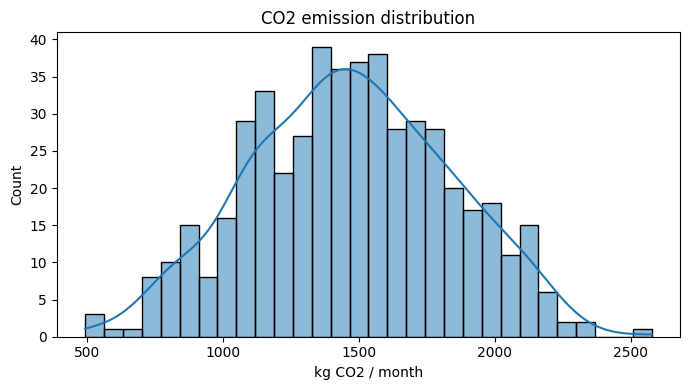

In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(df["estimated_co2_kg_per_month"], bins=30, kde=True)  # KDE overlay for shape inspection
plt.title("CO2 emission distribution")
plt.xlabel("kg CO2 / month")
plt.tight_layout()
plt.show()

Roughly normal, centred around 1500 kg/month — no heavy skew.

## feature distributions

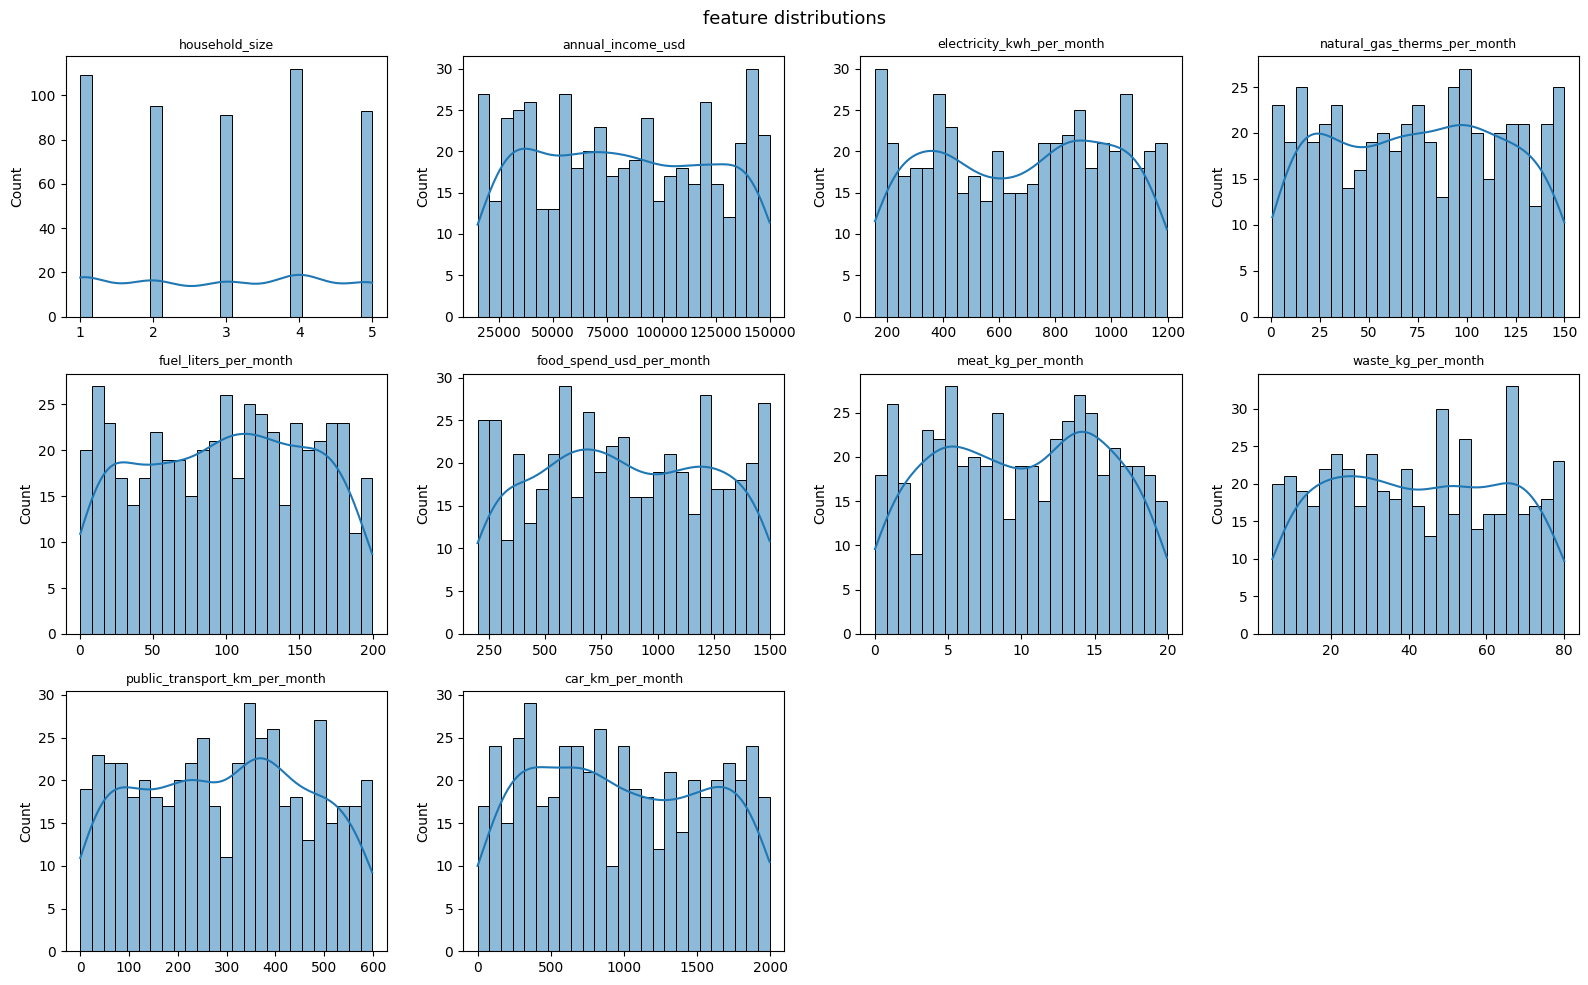

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()  # auto-select numeric features
numeric_cols.remove("estimated_co2_kg_per_month")  # exclude target from predictor plots

fig, axes = plt.subplots(3, 4, figsize=(16, 10))  # 3×4 grid for all features
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=25, kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)  # hide unused subplot slots

plt.suptitle("feature distributions", fontsize=13)
plt.tight_layout()
plt.show()

## correlation heatmap

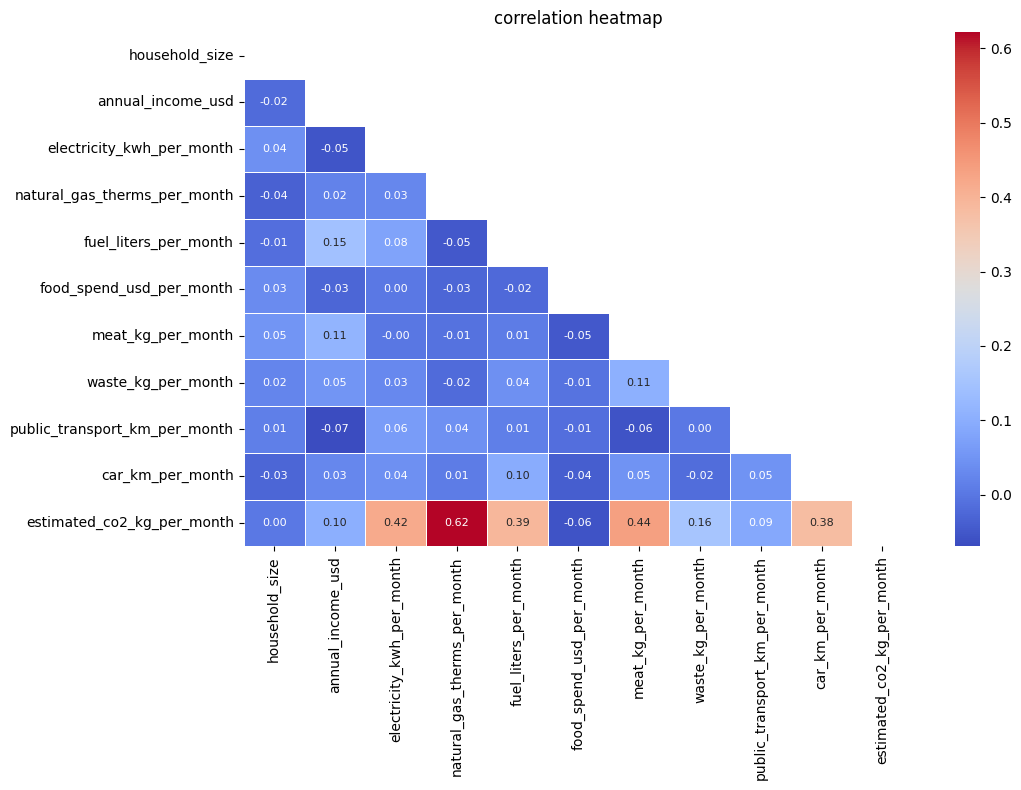

In [9]:
plt.figure(figsize=(11, 8))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper-triangle mask → avoid duplicate pairs
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, annot_kws={"size": 8})
plt.title("correlation heatmap")
plt.tight_layout()
plt.show()

Natural gas correlates most with CO2 (~0.6), then meat and electricity.

## scatter: key predictors vs target

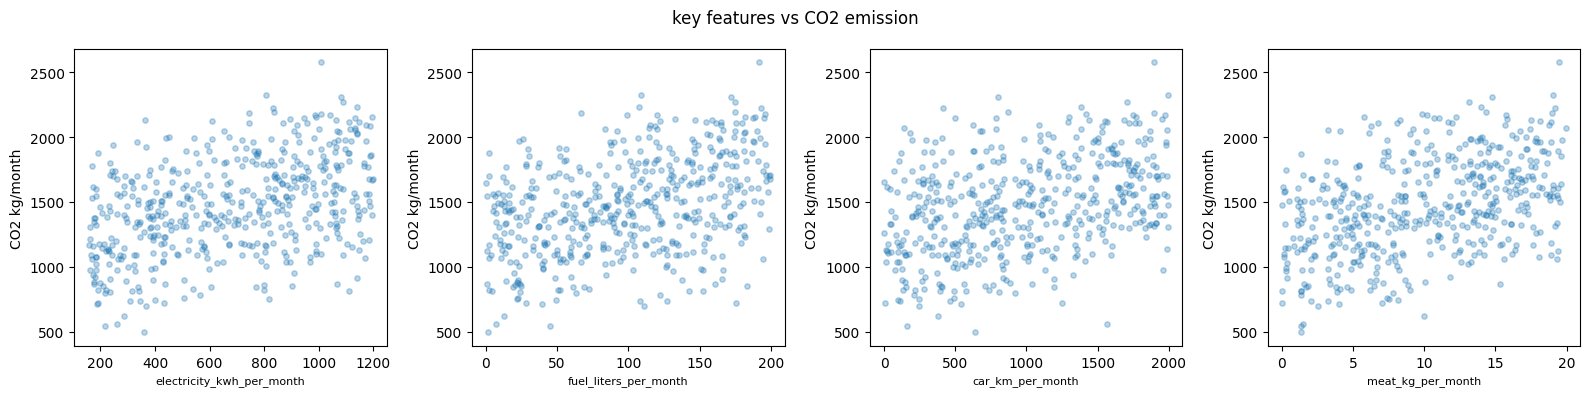

In [10]:
key_cols = ["electricity_kwh_per_month", "fuel_liters_per_month",
            "car_km_per_month", "meat_kg_per_month"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, key_cols):
    ax.scatter(df[col], df["estimated_co2_kg_per_month"],  # alpha=0.3 reduces overplotting
               alpha=0.3, s=15)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("CO2 kg/month")

plt.suptitle("key features vs CO2 emission")
plt.tight_layout()
plt.show()

## boxplots by household size

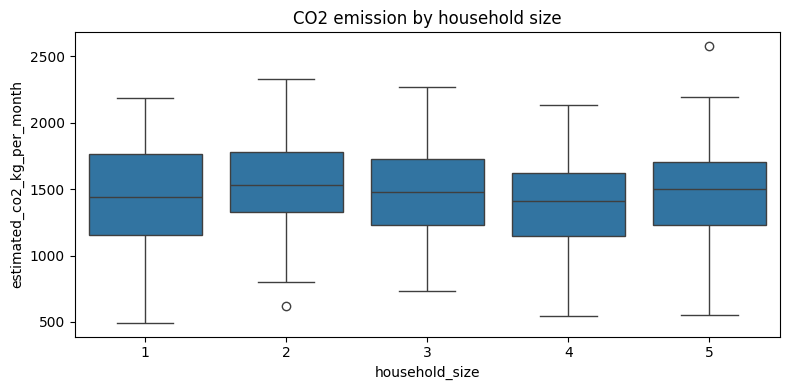

In [11]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="household_size", y="estimated_co2_kg_per_month", data=df)  # CO2 distribution per household size
plt.title("CO2 emission by household size")
plt.tight_layout()
plt.show()

Larger households have higher totals but lower per-person values.